In [3]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

In [4]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/ps_all_ITS2.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps
ps_prune <- prune_taxa(taxa_sums(ps) > 0, ps)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

In [5]:
## NaN because when sum(x)= zero x/sum(x)= NaN

# remove empty samples before normalizing 
ps_prune <- prune_samples(sample_sums(ps_prune) > 0, ps_prune)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 472 samples ]
sample_data() Sample Data:       [ 472 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

In [6]:
# cannot normalize its2 data same way as I normalized 16S
#glass et.al used the relative abundances from symportal instead

In [7]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented


ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))
   #converts raw counts into proportions (relative abundances
    # then scales it up to 1,000,000

## making ps object vegan compatible
- not sure if this is working with symportal data

In [8]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm) {
  sample_veg<- sample_data(ps_norm)
  return(as(sample_veg,"data.frame"))
}
#using phyloseq nmds plot 
sample_veg <- pssd2veg(ps_norm)

In [9]:
# convert the otu_table() within a phyloseq object to a vegan compatible data object
psotu2veg <- function(ps_norm) {
  otu_veg <- otu_table(ps_norm)
    
  if (taxa_are_rows(otu_veg)) {
    otu_veg <- t(otu_veg)
  }
  return(as(otu_veg, "matrix"))
}

# Extract normalized OTU matrix and sample data
otu_veg <- psotu2veg(ps_norm)

In [10]:
class(otu_veg)
class(sample_veg)

[1] "matrix" "array"

[1] "data.frame"

### clean sample_veg

In [11]:
head(sample_veg)

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,2,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,3,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,4,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,2024-01-10
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,4,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12
012024_BEL_CBC_T2_587_SSID,2_17_2025,48.8,,,Jan 2024,2_72,1/12/24,SSID,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,3,SR30N,267627,1457,Rhizangiidae,Siderastrea,sidera,202401112,8,2024-01-12
012024_BEL_CBC_T2_589_SSID,2_17_2025,47.6,,,Jan 2024,2_73,1/12/24,SSID,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,3,SR30N,267628,1457,Rhizangiidae,Siderastrea,sidera,20240112,8,2024-01-12


In [12]:
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_veg$SampleID <- rownames(sample_veg)

In [13]:
# now will have a new column that has Month Year instead of date_sampled
sample_veg$Month_year <- format(sample_veg$DateFormatted, "%b %Y")
sample_veg$Month_year <- factor(sample_veg$Month_year, levels = unique(sample_veg$Month_year))

#MonthYear in chronological order
# 2. reorder MonthYear as a factor in chronological order
sample_veg$Month_year <- factor(sample_veg$Month_year,
        levels = unique(sample_veg$Month_year[order(sample_veg$DateFormatted)])
)

In [14]:
#clean sample_veg

 #cleaning up meta to only be of interest
sample_clean<- sample_veg[, c("SampleID", "Health_status", "colony", "Date_ITS2", "Condition", "Species", "Month_year", "Seq_run", "Transect", "sample_uid")]
head(sample_clean)

,SampleID,Health_status,colony,Date_ITS2,Condition,Species,Month_year,Seq_run,Transect,sample_uid
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<int>
012024_BEL_CBC_T1_559_MCAV,012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,12_15_2025,Healthy,MCAV,Jan 2024,2,CBC30N,267721
012024_BEL_CBC_T1_561_OANN,012024_BEL_CBC_T1_561_OANN,Healthy,1_25,1_21_2026,Healthy,OANN,Jan 2024,3,CBC30N,267626
012024_BEL_CBC_T1_565_PAST,012024_BEL_CBC_T1_565_PAST,Bleached_Tissue,1_21,2_17_2026,CLP,PAST,Jan 2024,4,CBC30N,269104
012024_BEL_CBC_T2_585_OFAV,012024_BEL_CBC_T2_585_OFAV,Healthy,2_76,2_17_2026,Healthy,OFAV,Jan 2024,4,SR30N,269105
012024_BEL_CBC_T2_587_SSID,012024_BEL_CBC_T2_587_SSID,Bleached_Tissue,2_72,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267627
012024_BEL_CBC_T2_589_SSID,012024_BEL_CBC_T2_589_SSID,Bleached_Tissue,2_73,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267628


### cleaning asv table

### why NaN?
- because of phyloseq normalization

In [15]:
#why normalizing with symportal data does not work
head(otu_table(ps_norm))

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027480,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [16]:
head(otu_veg)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027480,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [17]:
class(otu_veg)

[1] "matrix" "array"

In [18]:
#check if there are any valeus that are 0 in otu_veg
#are there any samples with 0 across all symbint profiles
any(rowSums(otu_veg != 0) == 0)
#if so which ones

which(rowSums(otu_veg == 0) == ncol(otu_veg))

[1] FALSE

named integer(0)

In [19]:
#convert to df so it is compatible with sample data
otu_df <- as.data.frame(otu_veg)
#save sammple names as a column so tidy doesn't get rid of it during filtering
otu_df$SampleID <- rownames(otu_df)

In [20]:
head(otu_df)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851,SampleID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T2_585_OFAV
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T2_587_SSID
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T2_589_SSID


### merging asv and sample data 

In [21]:
otu_merged <- merge(otu_df, sample_clean, by = "SampleID",
                    all = TRUE, sort = FALSE)

In [22]:
head(otu_merged)

,SampleID,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,⋯,2027851,Health_status,colony,Date_ITS2,Condition,Species,Month_year,Seq_run,Transect,sample_uid
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<int>
1,012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_24,12_15_2025,Healthy,MCAV,Jan 2024,2,CBC30N,267721
2,012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_25,1_21_2026,Healthy,OANN,Jan 2024,3,CBC30N,267626
3,012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,1_21,2_17_2026,CLP,PAST,Jan 2024,4,CBC30N,269104
4,012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,2_76,2_17_2026,Healthy,OFAV,Jan 2024,4,SR30N,269105
5,012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_72,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267627
6,012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_73,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267628


In [23]:
rownames(otu_merged) <- otu_merged$SampleID
otu_merged$SampleID <- NULL
head(otu_merged)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027851,Health_status,colony,Date_ITS2,Condition,Species,Month_year,Seq_run,Transect,sample_uid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<int>
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_24,12_15_2025,Healthy,MCAV,Jan 2024,2,CBC30N,267721
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_25,1_21_2026,Healthy,OANN,Jan 2024,3,CBC30N,267626
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,1_21,2_17_2026,CLP,PAST,Jan 2024,4,CBC30N,269104
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,2_76,2_17_2026,Healthy,OFAV,Jan 2024,4,SR30N,269105
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_72,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267627
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_73,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267628


## what is driving ITS2 clustering?
- regression with ANOVA in vegan

### ways to test what drives ITS2 composition
- PERMANOVA (most common)
- multivariate GLMs (mvabund)
- compositional methods

## mcavs are clustering around all other corals, removing them to replot clustering

In [63]:
otu_nomcav <- otu_merged %>% 
  filter( Species != "MCAV")
head(otu_nomcav)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027851,Health_status,colony,Date_ITS2,Condition,Species,Month_year,Seq_run,Transect,sample_uid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<fct>,<chr>,<chr>,<fct>,<fct>,<int>,<chr>,<int>
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_25,1_21_2026,Healthy,OANN,Jan 2024,3,CBC30N,267626
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,1_21,2_17_2026,CLP,PAST,Jan 2024,4,CBC30N,269104
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,2_76,2_17_2026,Healthy,OFAV,Jan 2024,4,SR30N,269105
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_72,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267627
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_73,1_20_2026,CLB,SSID,Jan 2024,3,SR30N,267628
012024_BEL_CBC_T2_591_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,2_68,12_15_2025,Healthy,PAST,Jan 2024,2,SR30N,267722


In [64]:
num_nomcav <- otu_nomcav

# MCAVs are being weird can we ignore them?

In [52]:
common_samples <- intersect(rownames(otu_nomcav), rownames(sample_clean))

otu_nomcav <- otu_nomcav[common_samples, ]
sample_clean <- sample_clean[common_samples, ]
all(rownames(otu_nomcav) == rownames(sample_clean))

[1] TRUE

In [65]:
num_nomcav[, c("Health_status", "colony", "Date_ITS2", "Condition", "Species", "Month_year", "Seq_run", "Transect", "sample_uid")] <- list(NULL)
head(num_nomcav)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027480,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_591_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [66]:
# permanova

#this one is species within transect with date as another variable
adonis2(vegdist(num_nomcav, method = "bray") ~ Month_year + factor(Seq_run) + Species + colony + Health_status + Transect, data = sample_clean)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Month_year,11,5.4436558,0.033035778,1.1954600,0.002
factor(Seq_run),4,8.4550911,0.051311199,5.1061713,0.001
Species,4,6.7300940,0.040842753,4.0644166,0.001
colony,53,36.4144154,0.220987249,1.6597190,0.001
Health_status,3,0.9345646,0.005671568,0.7525323,1.000
Residual,258,106.8027969,0.648151453,NA,NA
Total,333,164.7806178,1.000000000,NA,NA


# plot nomcav permanova

In [67]:
# Hellinger distance, comparable to euclidean 
nomcav_ord <- decostand(num_nomcav, method = "hellinger")

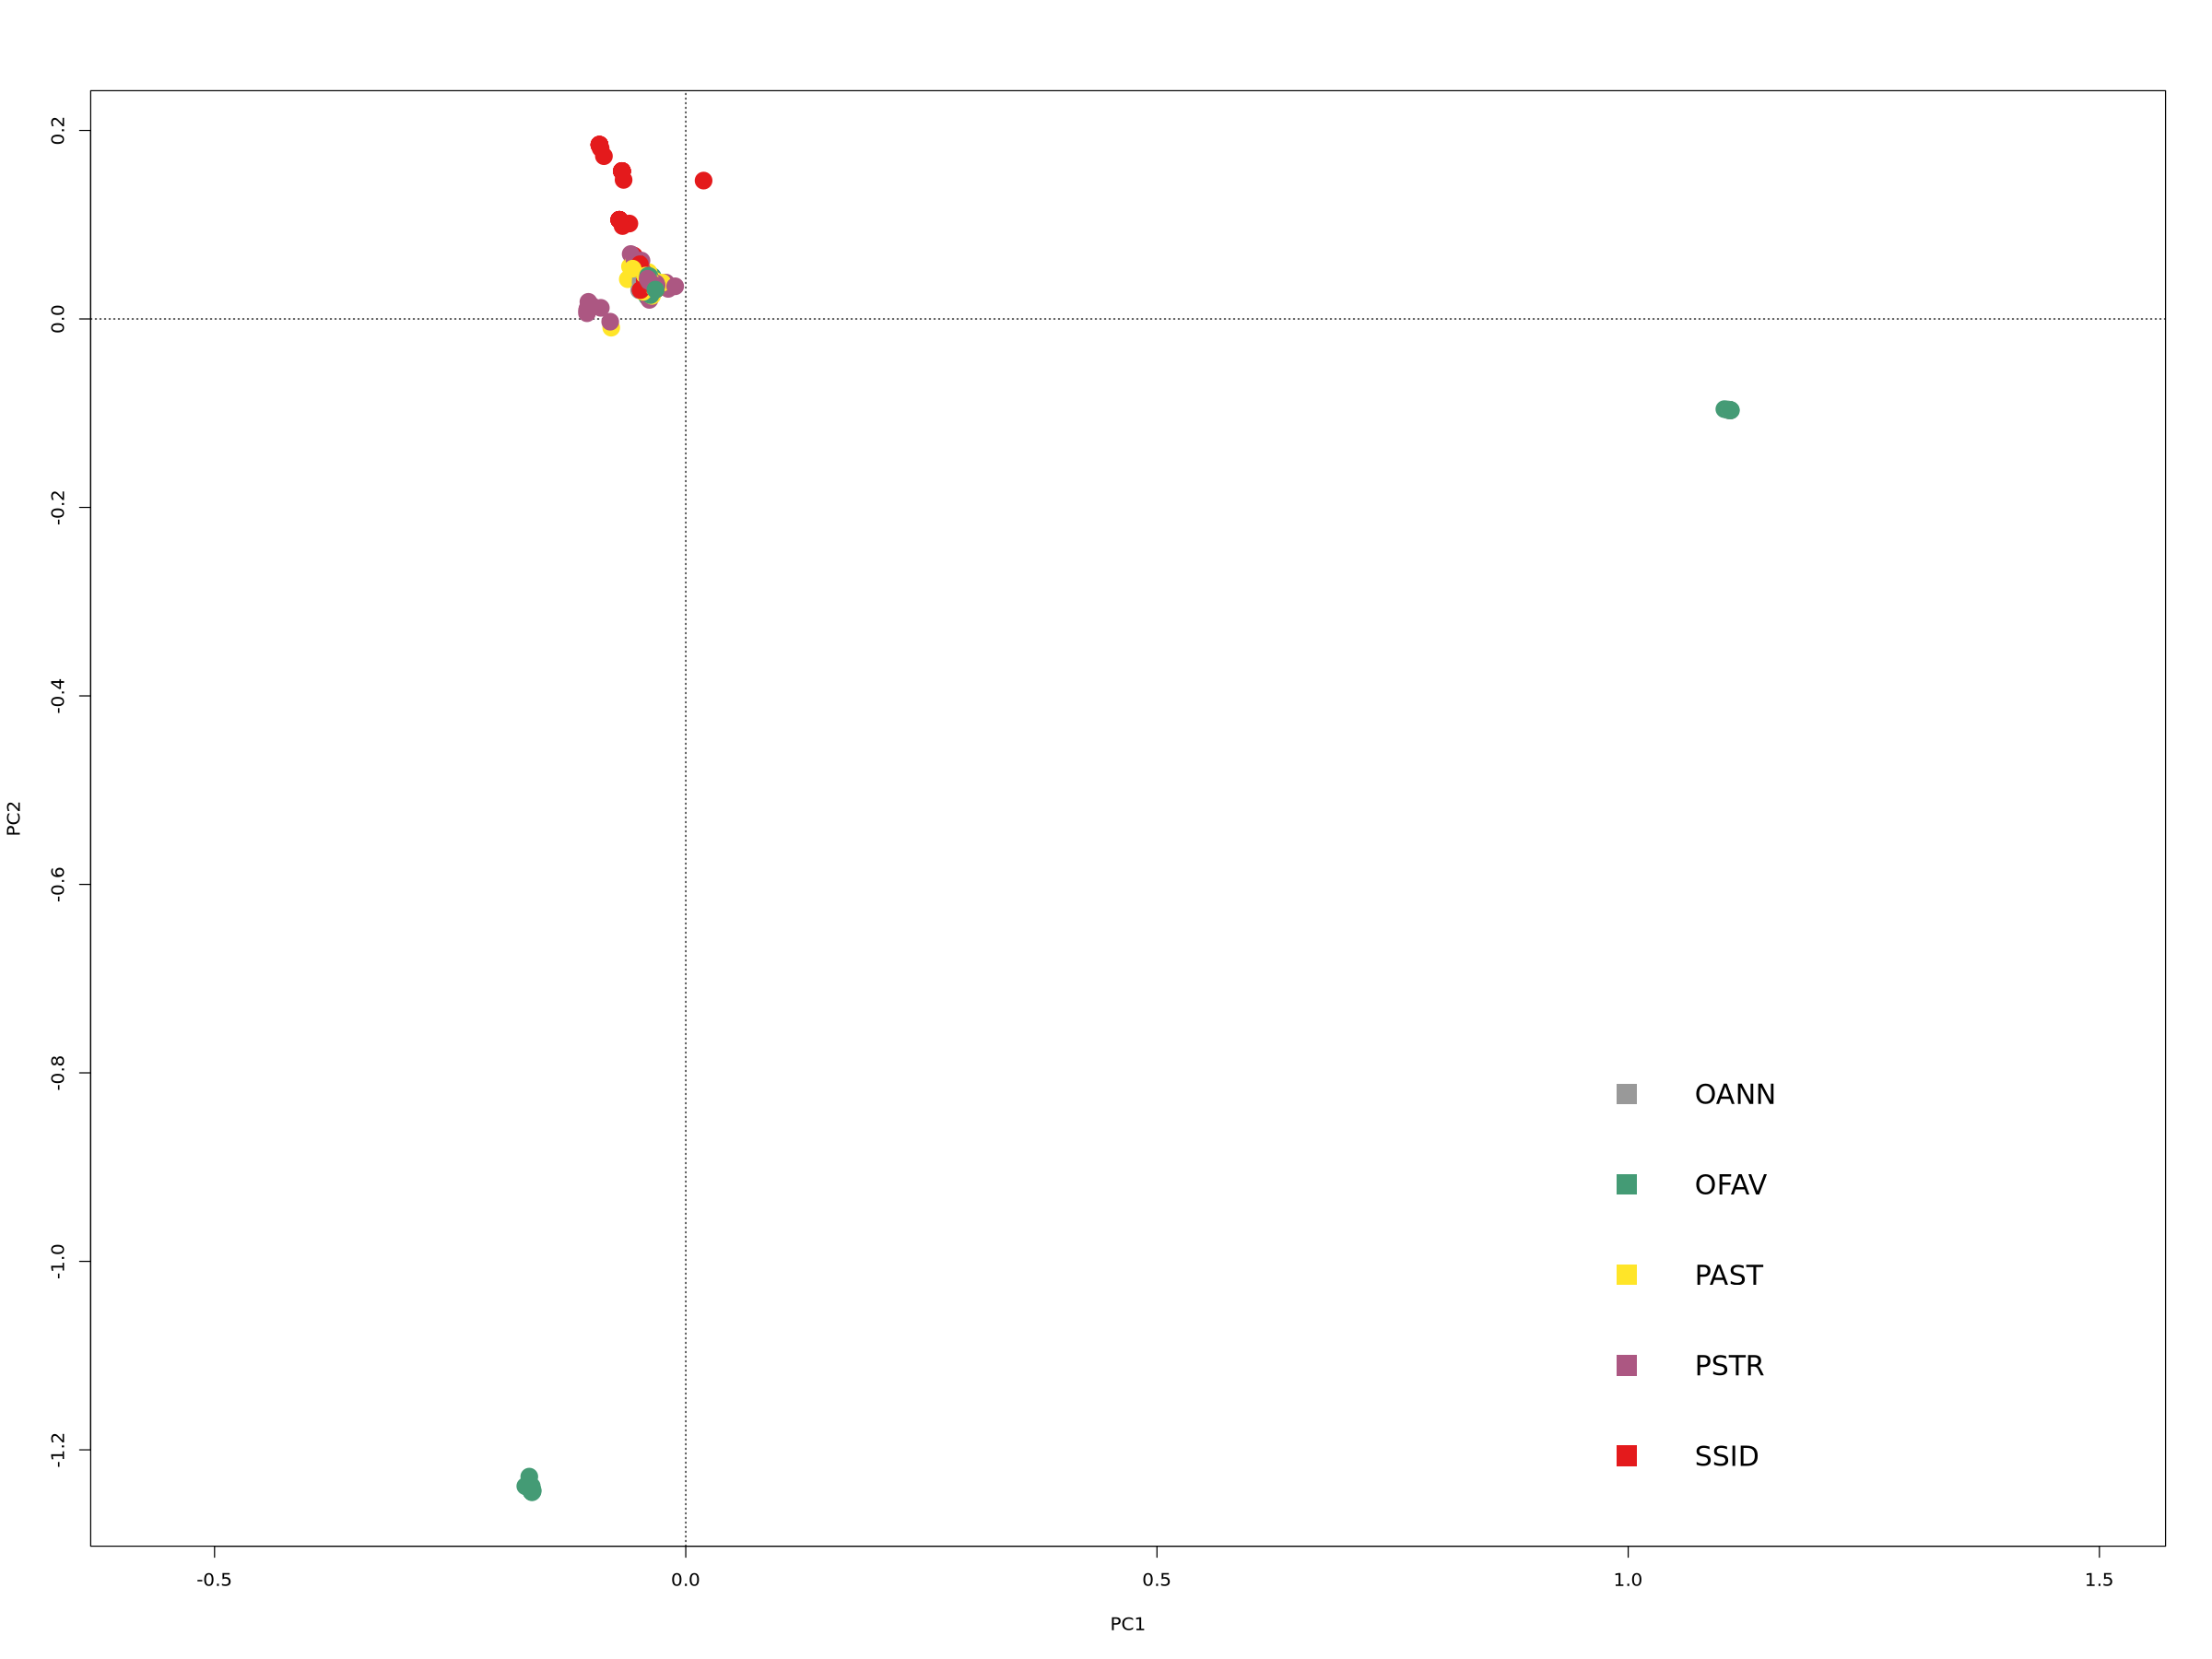

In [68]:
#transforming MonthYear col from chr to factor 
otu_nomcav$Species <- factor(otu_nomcav$Species)
# PCA via rda()
pca_spec <- rda(nomcav_ord)
#color points
# Color vector
col_spec <-colorRampPalette(brewer.pal(9, "Set1"))(6)
# Generate a random set of colors 
    col_spec <- sample(col_spec, 6)
cols <- col_spec[otu_nomcav$Species]

#plot
plot(pca_spec, type = "n", scaling = 2, display = "sites")

points(pca_spec, display = "sites", scaling = 2,
       pch = 19, col = cols, cex = 2)

legend("bottomright",
       legend = levels(otu_nomcav$Species),
       bty = "n",
       col = col_spec,
       pch = 15,
       cex = 1.5, pt.cex=2.5)

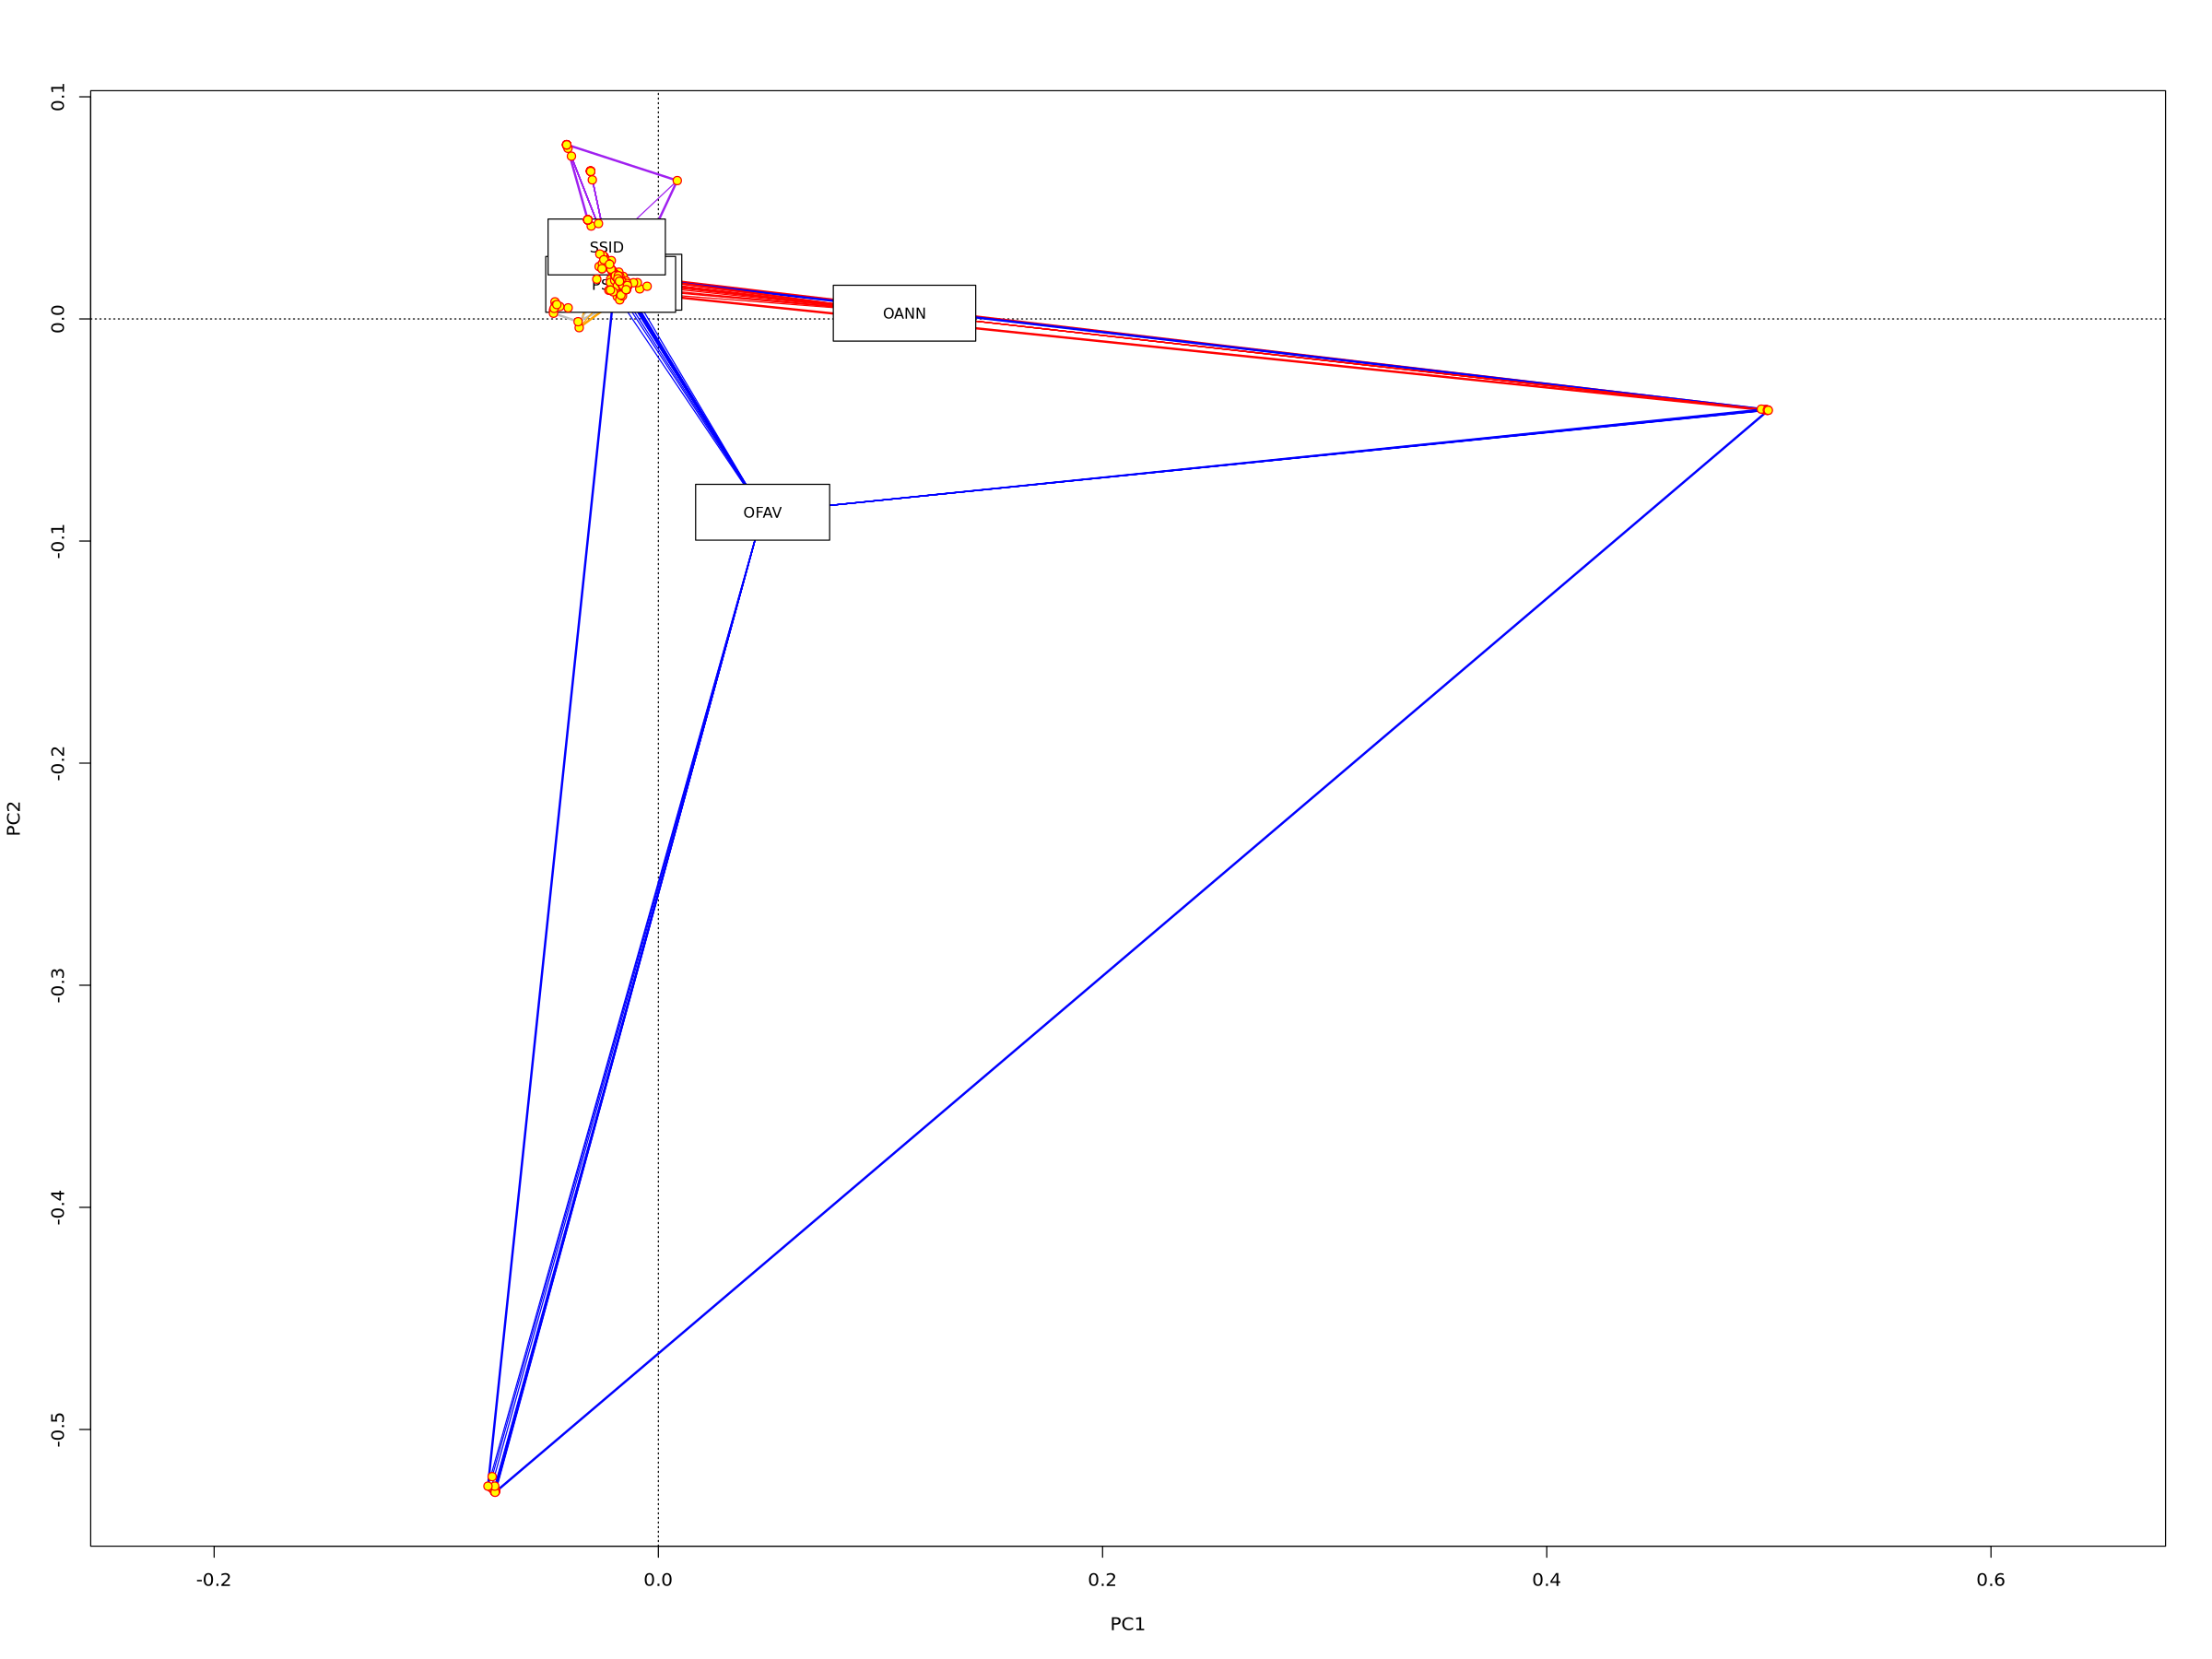

In [69]:
#by species 
disp <- "sites" 
scl <- "symmetric" 

#transforming species col from chr to factor 
otu_nomcav$Species <- factor(otu_nomcav$Species)
# PCA via rda()
pca_mod <- rda(nomcav_ord)
#color points
# Color vector
col_vec <-c("red", "blue", "orange", "grey", "purple", "green")
cols <- col_vec[otu_nomcav$Species]
plot(pca_mod, type = "n", scaling = scl, display = disp) 
ordihull(pca_mod, groups = otu_nomcav$Species, col = col_vec, scaling = scl, lwd = 2) 
ordispider(pca_mod, groups = otu_nomcav$Species, col = col_vec, scaling = scl, label = TRUE) 
points(pca_mod, display = disp, scaling = scl, pch = 21, col = "red", bg = "yellow")

# all species permanova

In [50]:
common_samples <- intersect(rownames(otu_veg), rownames(sample_clean))

otu_clean <- otu_veg[common_samples, ]
sample_clean <- sample_clean[common_samples, ]
all(rownames(otu_clean) == rownames(sample_clean))

[1] TRUE

## why only two degress freedom for  species?

In [28]:
#this one is species within transect with date as another variable
adonis2(vegdist(otu_clean, method = "bray") ~ Month_year + factor(Seq_run) + Species + Health_status + Transect, data = sample_clean)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Month_year,11,5.681806,0.024392611,1.143095,0.003
factor(Seq_run),4,12.030414,0.051647878,6.655939,0.001
Species,5,10.597968,0.045498235,4.690740,0.001
Health_status,3,1.458106,0.006259806,1.075614,0.154
Transect,3,2.082031,0.008938386,1.535871,0.001
Residual,445,201.081094,0.863263083,NA,NA
Total,471,232.931418,1.000000000,NA,NA


# permanova with all 

In [29]:
#this one is species within transect with date as another variable
adonis2(vegdist(otu_clean, method = "bray") ~ Month_year + factor(Seq_run) + colony+ Species + Health_status + Transect, data = sample_clean)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Month_year,11,5.681806,0.024392611,1.2453031,0.001
factor(Seq_run),4,12.030414,0.051647878,7.2510677,0.001
colony,79,58.869021,0.252731131,1.7965575,0.001
Species,2,1.021192,0.004384087,1.2310015,0.001
Health_status,3,1.030542,0.004424231,0.8281824,0.992
Residual,372,154.298445,0.662420062,NA,NA
Total,471,232.931418,1.000000000,NA,NA


In [30]:
#this one is species within transect with date as another variable
adonis2(vegdist(otu_clean, method = "bray") ~ Month_year + factor(Seq_run) + colony+ Health_status + Transect, data = sample_clean)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Month_year,11,5.681806,0.024392611,1.2437723,0.001
factor(Seq_run),4,12.030414,0.051647878,7.2421542,0.001
colony,79,58.869021,0.252731131,1.7943490,0.001
Health_status,3,1.031245,0.004427246,0.8277281,0.991
Residual,374,155.318934,0.666801133,NA,NA
Total,471,232.931418,1.000000000,NA,NA


In [38]:
head(otu_clean)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027480,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_561_OANN,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_589_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


## now we see that species has the second highest R2 value
- lets look at PC plots for clustering

In [32]:
# Hellinger distance, comparable to euclidean 
ord <- decostand(otu_clean, method = "hellinger")

In [33]:
# plot settings
options(repr.plot.width=20, repr.plot.height=15)

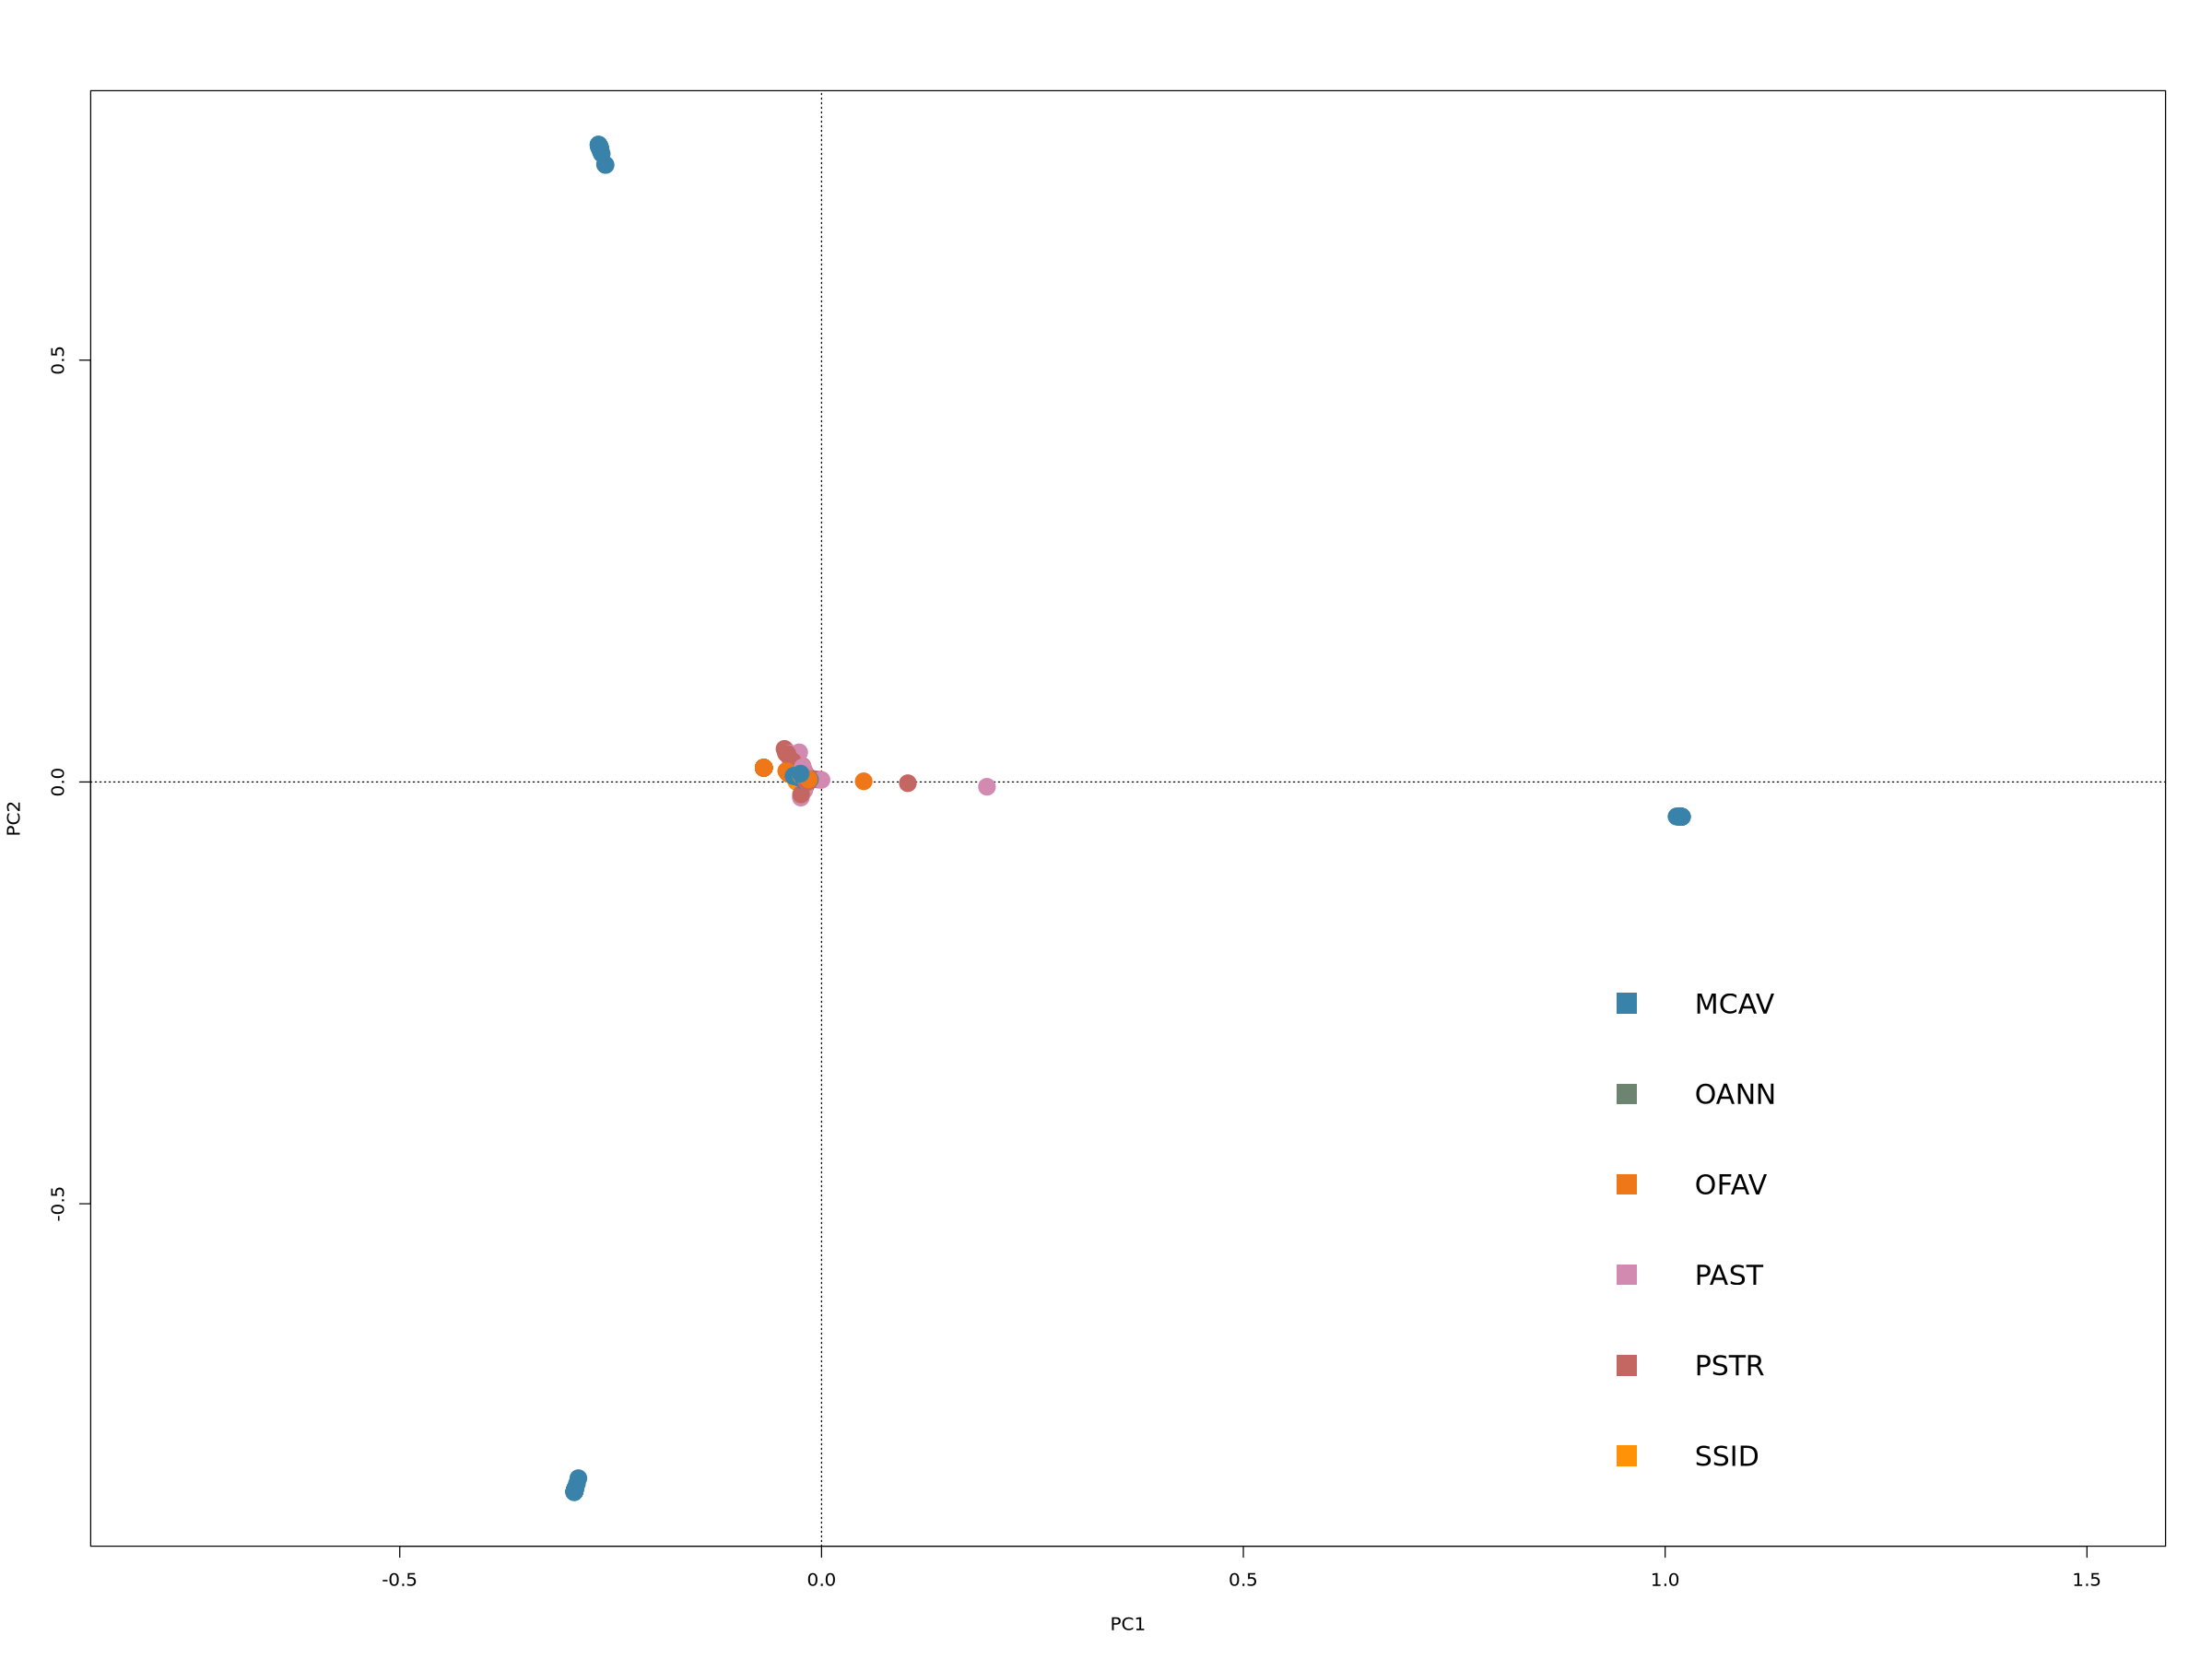

In [35]:
#transforming MonthYear col from chr to factor 
otu_merged$Species <- factor(otu_merged$Species)
# PCA via rda()
pca_spec <- rda(ord)
#color points
# Color vector
col_spec <-colorRampPalette(brewer.pal(9, "Set1"))(80)
# Generate a random set of colors 
    col_spec <- sample(col_spec, 80)
cols <- col_spec[otu_merged$Species]

#plot
plot(pca_spec, type = "n", scaling = 2, display = "sites")

points(pca_spec, display = "sites", scaling = 2,
       pch = 19, col = cols, cex = 2)

legend("bottomright",
       legend = levels(otu_merged$Species),
       bty = "n",
       col = col_spec,
       pch = 15,
       cex = 1.5, pt.cex=2.5)

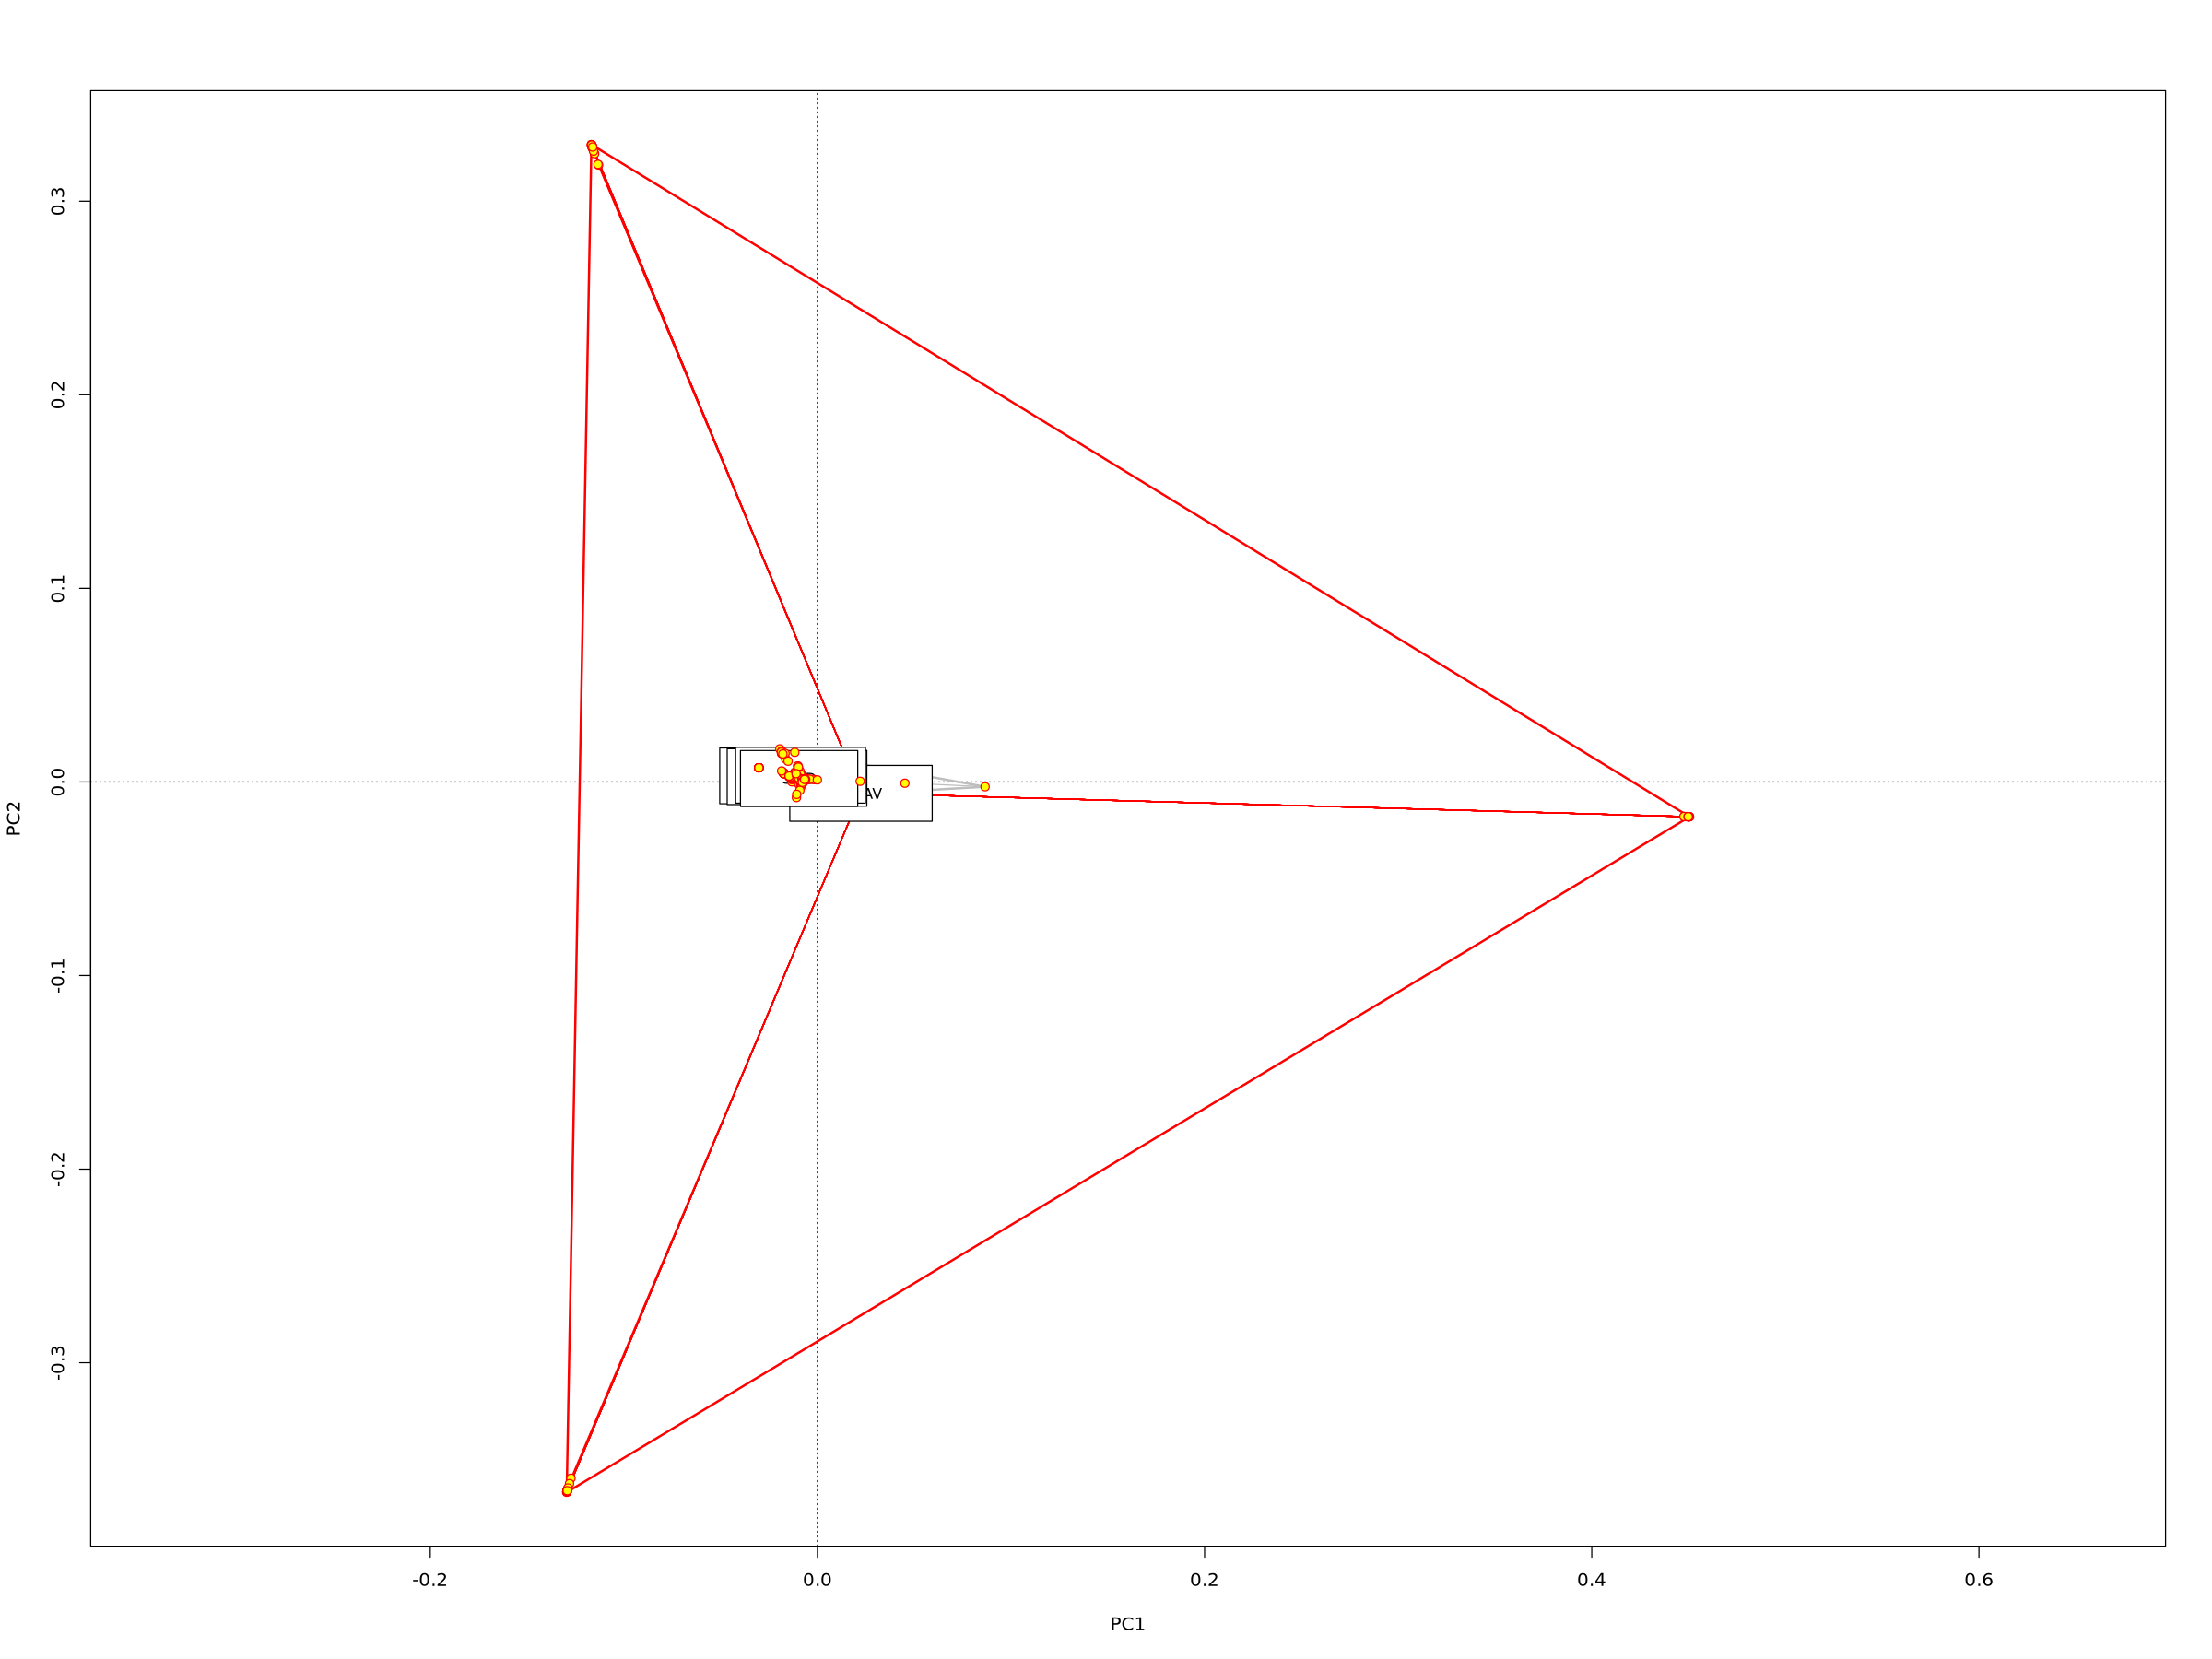

In [36]:
#by species 
disp <- "sites" 
scl <- "symmetric" 

#transforming species col from chr to factor 
otu_merged$Species <- factor(otu_merged$Species)
# PCA via rda()
pca_mod <- rda(ord)
#color points
# Color vector
col_vec <-c("red", "blue", "orange", "grey", "purple", "green")
cols <- col_vec[otu_merged$Species]
plot(pca_mod, type = "n", scaling = scl, display = disp) 
ordihull(pca_mod, groups = otu_merged$Species, col = col_vec, scaling = scl, lwd = 2) 
ordispider(pca_mod, groups = otu_merged$Species, col = col_vec, scaling = scl, label = TRUE) 
points(pca_mod, display = disp, scaling = scl, pch = 21, col = "red", bg = "yellow")

## anova with taxa

ANOVA works best when:

-Each row = one observation
-Variables = columns
-The response variable is a single column (not spread across many)

In [91]:
taxa <- read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/symportal_taxa.csv")

In [96]:
otu_long <- otu_df %>%
  pivot_longer(
    cols = -SampleID,  
    names_to = "ITS2.type.profile.UID",
    values_to = "abundance"
  )

In [97]:
head(otu_long)

SampleID,ITS2.type.profile.UID,abundance
<chr>,<chr>,<dbl>
012024_BEL_CBC_T1_557_SSID,1661676,0
012024_BEL_CBC_T1_557_SSID,1661811,0
012024_BEL_CBC_T1_557_SSID,1661272,0
012024_BEL_CBC_T1_557_SSID,1661422,0
012024_BEL_CBC_T1_557_SSID,1661525,0
012024_BEL_CBC_T1_557_SSID,1661677,0


In [101]:
str(otu_long$ITS2.type.profile.UID)
str(taxa$ITS2.type.profile.UID)

#convert taxaITS2.type.profile to chr
taxa$ITS2.type.profile.UID <- as.character(taxa$ITS2.type.profile.UID)

 chr [1:198075] "1661676" "1661811" "1661272" "1661422" "1661525" "1661677" ...
 int [1:417] 1661676 1661811 1661272 1661422 1661525 1661677 1661737 1669273 1661179 1661509 ...


In [102]:
otu_taxa <- otu_long %>%
  left_join(taxa, by = "ITS2.type.profile.UID")

In [103]:
head(otu_taxa)

SampleID,ITS2.type.profile.UID,abundance,X,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
012024_BEL_CBC_T1_557_SSID,1661676,0,1,A,A3/A4/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",21,26,A3/A4/A13-A4a,22385/29206/8181-40166,0.634[0.211]/0.150[0.114]-0.111[0.095]/0.105[0.186]
012024_BEL_CBC_T1_557_SSID,1661811,0,2,A,A3,"Symbiodinium natans,Symbiodinium tridacnidorum",11,230,A3,22385,1.000[0.000]
012024_BEL_CBC_T1_557_SSID,1661272,0,3,A,A3/A4,"Symbiodinium natans,Symbiodinium tridacnidorum",10,22,A3/A4/A4a,22385/29206-40166,0.657[0.295]/0.198[0.147]-0.144[0.151]
012024_BEL_CBC_T1_557_SSID,1661422,0,4,A,A3bb/A3bt,None,9,322,A3bb/A3bt,,0.515[0.062]/0.485[0.062]
012024_BEL_CBC_T1_557_SSID,1661525,0,5,A,A3/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",8,28,A3/A13,,0.627[0.220]/0.373[0.220]
012024_BEL_CBC_T1_557_SSID,1661677,0,6,A,A4/A3/A4a,"Symbiodinium natans,Symbiodinium tridacnidorum",8,8,A4/A3/A4a-A4d,29206/22385/40166-29900,0.330[0.130]/0.292[0.241]/0.288[0.136]-0.089[0.061]


In [104]:
# join sample data
full_data <- otu_taxa %>%
  left_join(sample_clean, by = "SampleID")

In [106]:
taxa.anov <- aov(abundance ~ Date_ITS2 + factor(Month_year) + Seq_run + Species + Health_status, data = full_data)
summary(taxa.anov)

                       Df    Sum Sq   Mean Sq F value Pr(>F)
Date_ITS2              25 1.393e+09 5.574e+07   0.026  1.000
factor(Month_year)     11 3.123e+08 2.839e+07   0.013  1.000
Seq_run                 1 8.138e+06 8.138e+06   0.004  0.951
Species                 5 3.863e+07 7.726e+06   0.004  1.000
Health_status           3 2.276e+07 7.588e+06   0.004  1.000
Residuals          198029 4.268e+14 2.155e+09               

## nmds plots 